# Comparing FWCP Estimators on Simulated Data

This notebook checks whether the FWCP estimators in `fwcp.py` are numerically aligned on many simulated wage-growth samples.

The idea is simple:

- simulate many datasets with varying asymmetry, dispersion, and zero-growth bunching
- run each FWCP estimator on every simulated dataset
- inspect their pairwise relationships with scatter plots and a correlation matrix

Strong positive alignment does not mean the estimators are identical, but it is a useful consistency check.

In [5]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import tqdm

from fwcp import (
    BunchingEstimator,
    HoldenWulfsberg2009Estimator,
    RuleOfThumbEstimator,
    SymmetricEstimator,
)

plt.style.use('ggplot')
rng = np.random.default_rng(20260421)

## Simulation design

Each simulated sample is a mixture of:

- a smooth baseline wage-growth distribution
- a small point-mass-like bunching region around zero
- optional left-tail stress to generate more asymmetry across replications

This is not meant to be a structural DNWR model. It is a stress-test bed for estimator consistency.

In [6]:
def simulate_actual_sample(rng, n_base=2200):
    loc = rng.uniform(-0.01, 0.05)
    scale = rng.uniform(0.06, 0.16)
    spike_share = rng.uniform(0.0, 0.12)
    left_tail_share = rng.uniform(0.0, 0.10)

    n_spike = int(round(n_base * spike_share))
    n_left = int(round(n_base * left_tail_share))
    n_main = n_base - n_spike - n_left

    main = rng.normal(loc=loc, scale=scale, size=n_main)
    spike = rng.uniform(-0.01, 0.01, size=n_spike)
    left = rng.normal(loc=loc - rng.uniform(0.03, 0.10), scale=scale * rng.uniform(0.7, 1.2), size=n_left)

    x = np.concatenate([main, spike, left])
    return np.clip(x, -0.6, 0.8)


def simulate_reference_sample(rng, n_ref=3500):
    loc = rng.uniform(0.03, 0.08)
    scale = rng.uniform(0.08, 0.20)
    ref = rng.laplace(loc=loc, scale=scale, size=n_ref)
    return np.clip(ref, -0.6, 0.8)


## Run many simulations

For speed, the estimators below use fixed smoothing settings instead of cross-validation. You can raise `n_sims` if you want a larger Monte Carlo experiment.

In [7]:
n_sims = 200
xlim = (-0.6, 0.8)
bin_width = 0.02

results = []

for sim_id in tqdm.tqdm(range(n_sims)):
    actual = simulate_actual_sample(rng)
    reference = simulate_reference_sample(rng)

    bunch = BunchingEstimator(
        bin_width=bin_width,
        xlim=xlim,
        degree=14,
        alpha=1e-3,
        cv=False,
    ).fit(actual)

    sym = SymmetricEstimator(
        bin_width=bin_width,
        xlim=xlim,
        degree=14,
        alpha=1e-3,
        cv=False,
        symmetry_type='median',
        centering=True,
    ).fit(actual)

    hw = HoldenWulfsberg2009Estimator(reference).fit(actual)
    rule = RuleOfThumbEstimator().fit(actual)

    results.append({
        'bunching_relative': bunch.fwcp_relative,
        'bunching_absolute': bunch.fwcp_absolute,
        'symmetric_unweighted': sym.fwcp_absolute,
        'symmetric_weighted': sym.fwcp_relative,
        'hw_frequency': hw.fwcp_frequency(),
        'hw_unweighted': hw.fwcp_integral(weighted=False),
        'hw_weighted': hw.fwcp_integral(weighted=True),
        'rule_of_thumb': rule.fwcp_relative,
        'observed_share_below_zero': np.mean(actual < 0),
    })

results = {k: np.array([row[k] for row in results], dtype=float) for k in results[0]}
metric_names = [
    'bunching_relative',
    'symmetric_unweighted',
    'symmetric_weighted',
    'hw_frequency',
    'hw_unweighted',
    'hw_weighted',
    'rule_of_thumb',
]

summary = {name: (float(np.mean(results[name])), float(np.std(results[name]))) for name in metric_names}
summary

100%|██████████| 200/200 [15:14<00:00,  4.57s/it]


{'bunching_relative': (0.46724978605847395, 0.17364552855475762),
 'symmetric_unweighted': (0.015905229257445645, 0.045294116662329305),
 'symmetric_weighted': (0.00300009624594088, 0.007593153704326235),
 'hw_frequency': (0.013253889220305343, 0.029284067236603182),
 'hw_unweighted': (0.0024279687032946213, 0.011644248306830146),
 'hw_weighted': (0.009530759368254099, 0.00447912382551631),
 'rule_of_thumb': (0.1114181818181818, 0.13786113027126037)}

In [8]:
for name in metric_names:
    mean_val, sd_val = summary[name]
    print(f'{name:>22s}  mean = {mean_val: .4f}   sd = {sd_val: .4f}')

     bunching_relative  mean =  0.4672   sd =  0.1736
  symmetric_unweighted  mean =  0.0159   sd =  0.0453
    symmetric_weighted  mean =  0.0030   sd =  0.0076
          hw_frequency  mean =  0.0133   sd =  0.0293
         hw_unweighted  mean =  0.0024   sd =  0.0116
           hw_weighted  mean =  0.0095   sd =  0.0045
         rule_of_thumb  mean =  0.1114   sd =  0.1379


## Scatter plot matrix

The diagonal shows each estimator's marginal distribution across simulations. Off-diagonal panels show pairwise scatter plots, with the correlation printed in each panel title.

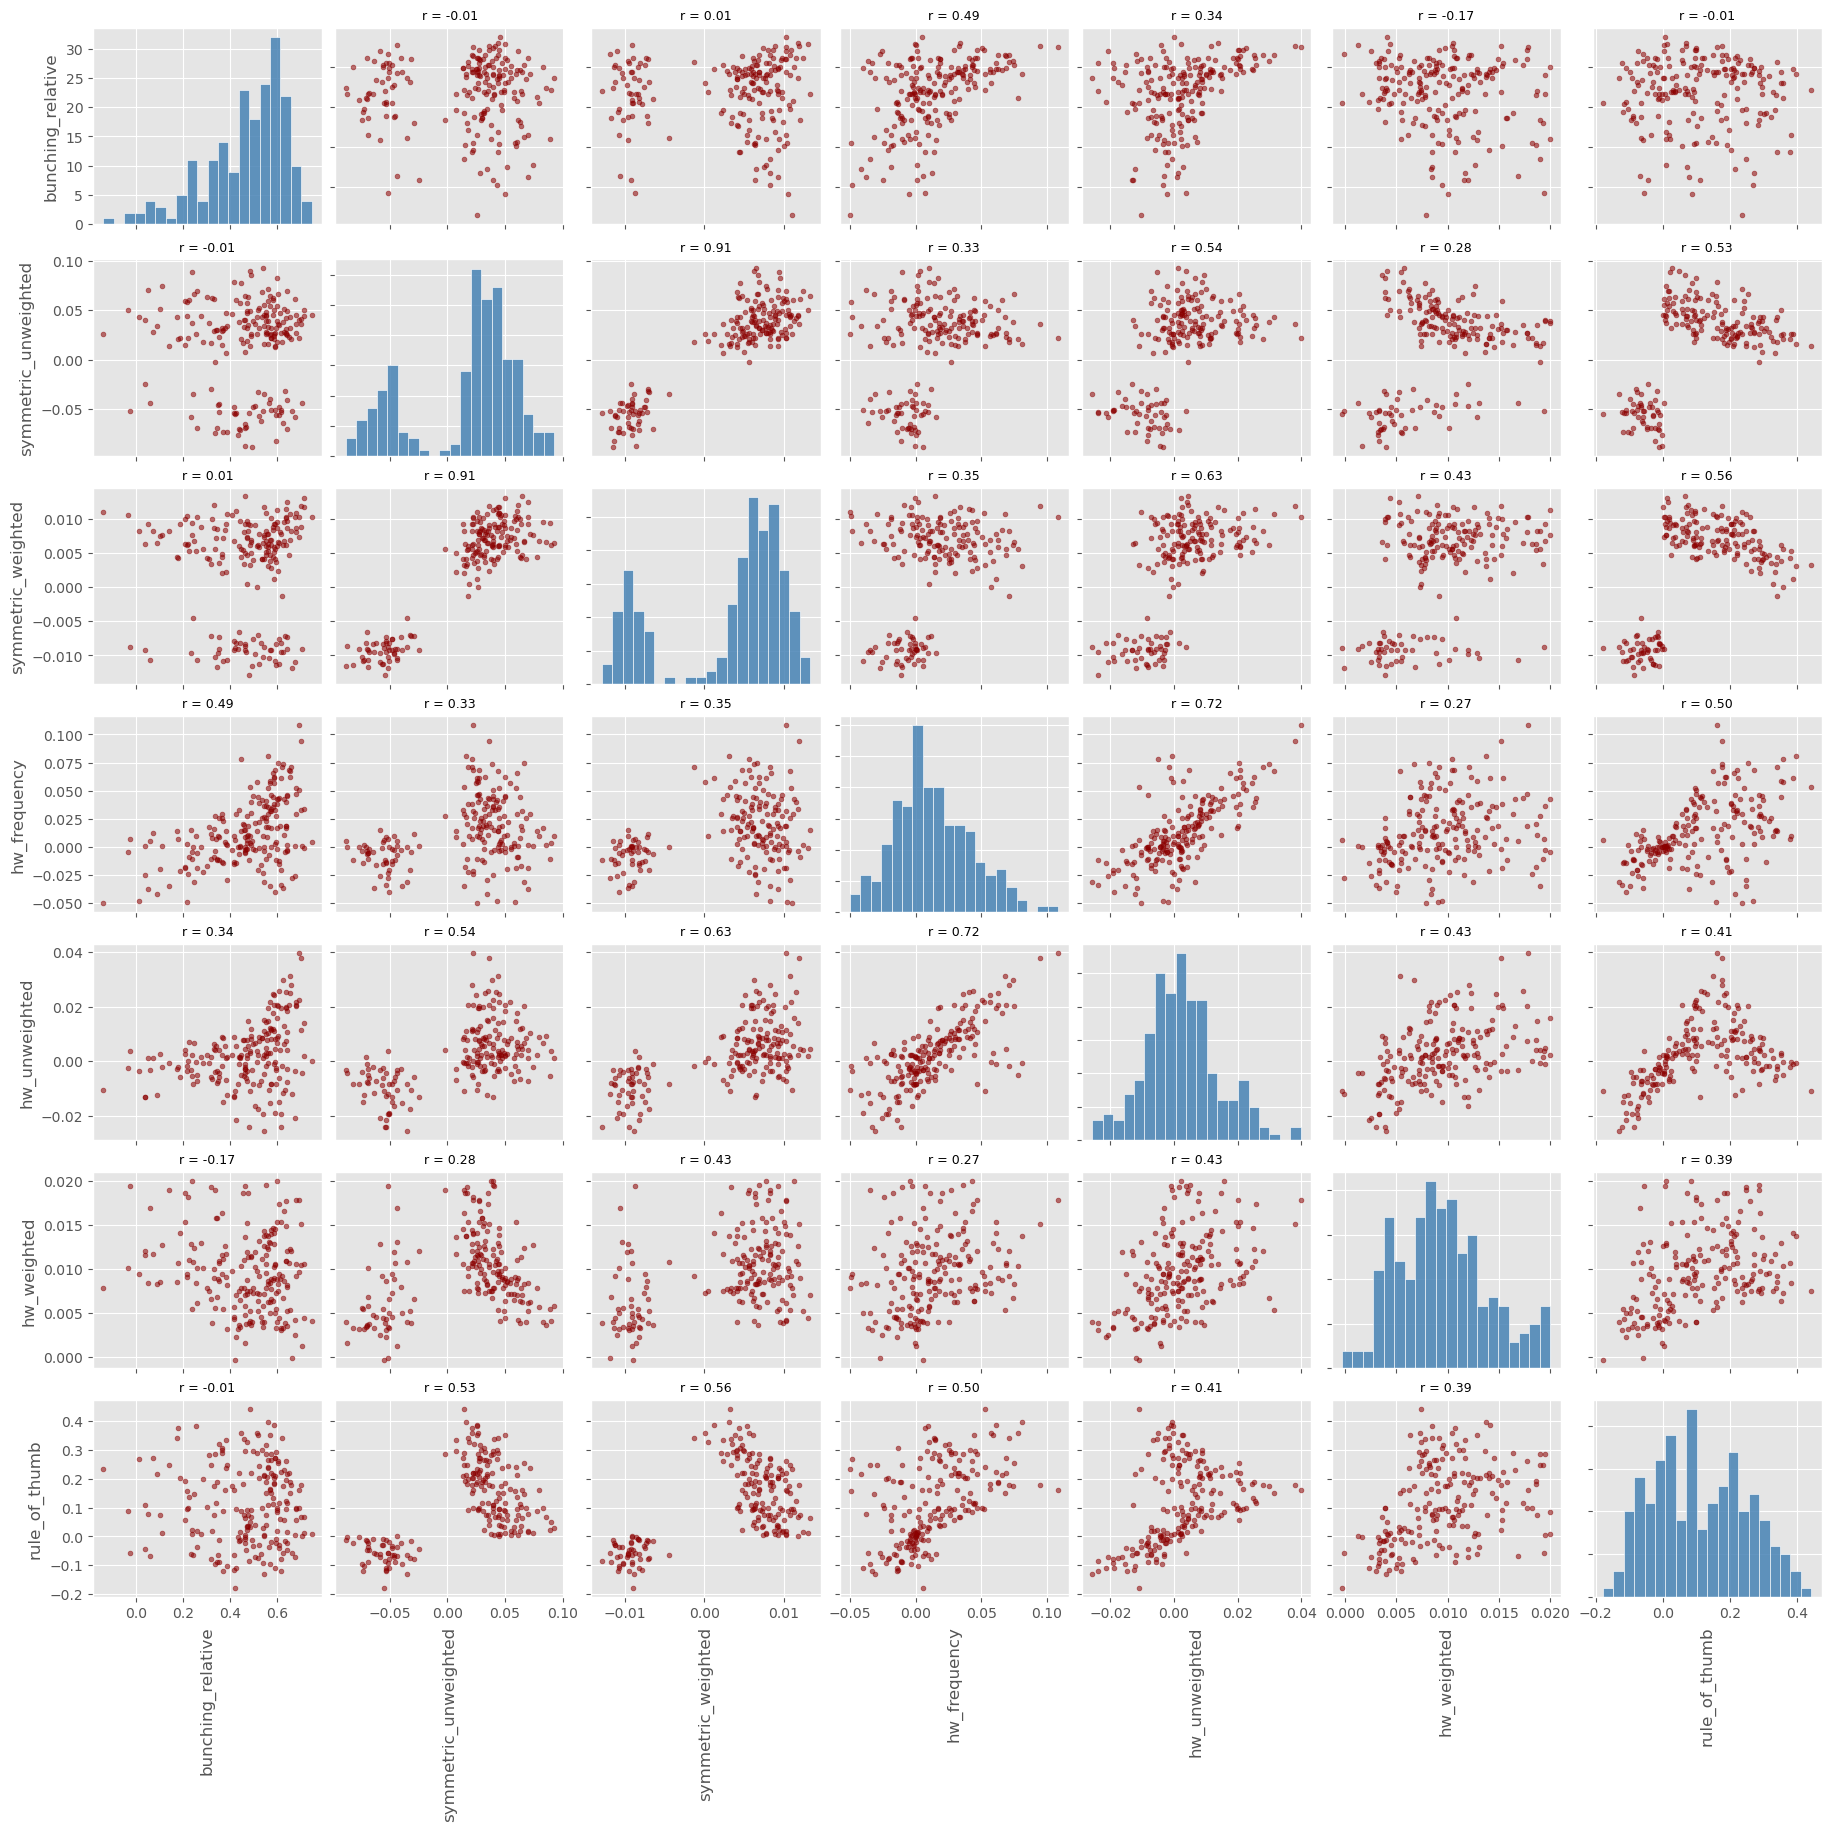

In [9]:
n = len(metric_names)
fig, axes = plt.subplots(n, n, figsize=(2.6 * n, 2.6 * n), constrained_layout=True)

for i, y_name in enumerate(metric_names):
    for j, x_name in enumerate(metric_names):
        ax = axes[i, j]
        x = results[x_name]
        y = results[y_name]

        if i == j:
            ax.hist(x, bins=20, color='steelblue', alpha=0.85, edgecolor='white')
        else:
            corr = np.corrcoef(x, y)[0, 1]
            ax.scatter(x, y, s=12, alpha=0.55, color='darkred')
            ax.set_title(f'r = {corr:.2f}', fontsize=9)

        if i == n - 1:
            ax.set_xlabel(x_name, rotation=90)
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(y_name)
        else:
            ax.set_yticklabels([])

plt.show()

## Correlation matrix

This heatmap summarizes pairwise linear alignment across the simulated datasets.

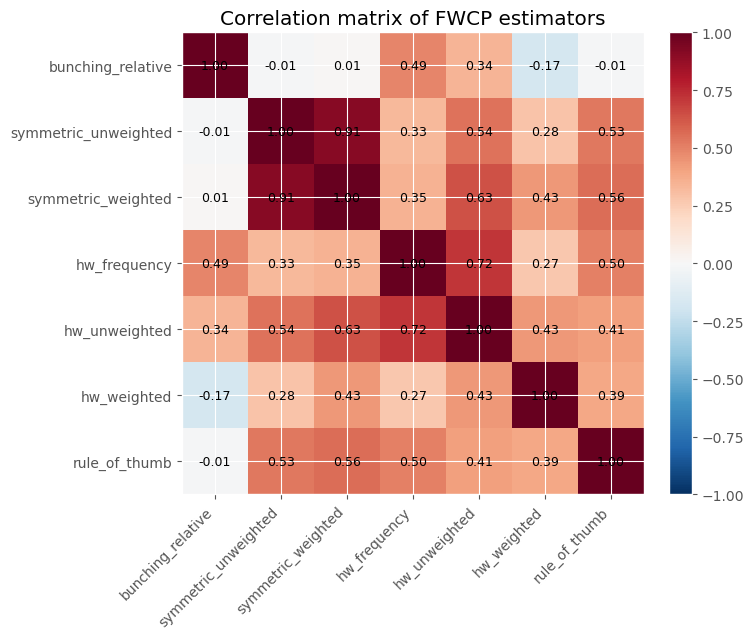

In [10]:
corr = np.corrcoef(np.vstack([results[name] for name in metric_names]))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(np.arange(len(metric_names)))
ax.set_yticks(np.arange(len(metric_names)))
ax.set_xticklabels(metric_names, rotation=45, ha='right')
ax.set_yticklabels(metric_names)
ax.set_title('Correlation matrix of FWCP estimators')

for i, j in itertools.product(range(len(metric_names)), range(len(metric_names))):
    ax.text(j, i, f'{corr[i, j]:.2f}', ha='center', va='center', color='black', fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Focused pairwise checks

These panels highlight a few especially interesting comparisons often discussed in practice.

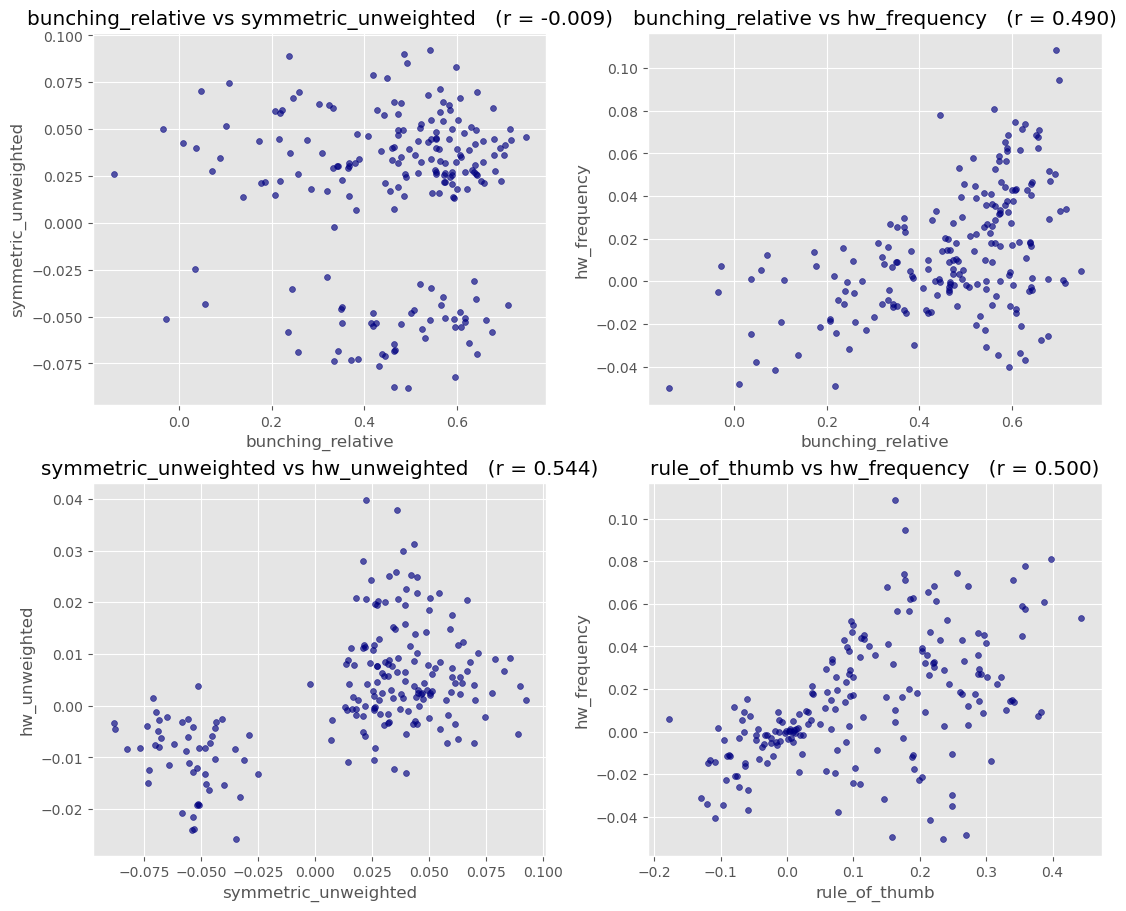

In [11]:
pairs = [
    ('bunching_relative', 'symmetric_unweighted'),
    ('bunching_relative', 'hw_frequency'),
    ('symmetric_unweighted', 'hw_unweighted'),
    ('rule_of_thumb', 'hw_frequency'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9), constrained_layout=True)
for ax, (x_name, y_name) in zip(axes.ravel(), pairs):
    x = results[x_name]
    y = results[y_name]
    corr_xy = np.corrcoef(x, y)[0, 1]
    ax.scatter(x, y, s=18, alpha=0.65, color='navy')
    ax.set_xlabel(x_name)
    ax.set_ylabel(y_name)
    ax.set_title(f'{x_name} vs {y_name}   (r = {corr_xy:.3f})')

plt.show()

## Interpretation notes

Things to look for:

- positive pairwise correlations across most estimator pairs
- similar ranking of simulations from low FWCP to high FWCP
- stronger agreement among estimators designed to target similar notions of excess mass or asymmetry

Differences are expected because the estimators use different identifying assumptions:

- `bunching_relative` is local and focuses on the kink bin
- `symmetric_*` is shape-based and uses mirroring around a center
- `hw_*` borrows strength from an external or reference sample
- `rule_of_thumb` is the strongest and simplest symmetry-about-zero approximation
